In [1]:
#Final Assignment ITC300
#Hamidullah Rezae
#Professor Ahmad Al-Janad

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../Data/HealthCareData.csv")

In [3]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
df.shape #The data has 4909 rows and 12 columns

(5110, 12)

In [5]:
df.isnull().any() #We check whether the data has null values

id                   False
gender               False
age                  False
hypertension         False
heart_disease        False
ever_married         False
work_type            False
Residence_type       False
avg_glucose_level    False
bmi                   True
smoking_status       False
stroke               False
dtype: bool

In [6]:
df.dropna(inplace=True) #We remove null values from our dataset

In [7]:
df.isnull().any().any() #Generally there is no null values now

False

In [8]:
#Question 1: What is the total number of married men who experienced heart disease?

TotalNumberofMen = df[(df["gender"]=="Male") & (df["ever_married"]=="Yes") & (df["heart_disease"]==1)]

In [9]:
len(TotalNumberofMen) #The total number of married men who experienced heart disease is 130

130

In [10]:
#Question 2: How many female participants experienced stroke that had never smoked in their lives?

FemaleParticipants = df[(df["gender"]=="Female") & (df["smoking_status"]=="never smoked") & (df["stroke"]==1)]

In [11]:
FemaleParticipants.count() #The total number of female participants who experienced stroke but had never smoked is 59

id                   59
gender               59
age                  59
hypertension         59
heart_disease        59
ever_married         59
work_type            59
Residence_type       59
avg_glucose_level    59
bmi                  59
smoking_status       59
stroke               59
dtype: int64

In [12]:
#Question 3: What is the maximum, minimum, count, mean and median of particpants' age based on their gender?


In [13]:
df.groupby("gender").age.agg(["max", "min", "count", "mean", "median"]) 

,max,min,count,mean,median
gender,,,,,
Female,82.0,0.08,2897,43.437805,44.0
Male,82.0,0.08,2011,42.049130,45.0
Other,26.0,26.00,1,26.000000,26.0


In [14]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1


In [15]:
#Question 4: Which group of married male participants has the highet bmi rate based on the smoking status?

MarriedParticipants = df.groupby(["smoking_status"]).sum()[["bmi"]]

In [16]:
MarriedParticipants

,bmi
smoking_status,
Unknown,38063.2
formerly smoked,25735.4
never smoked,55527.7
smokes,22510.6


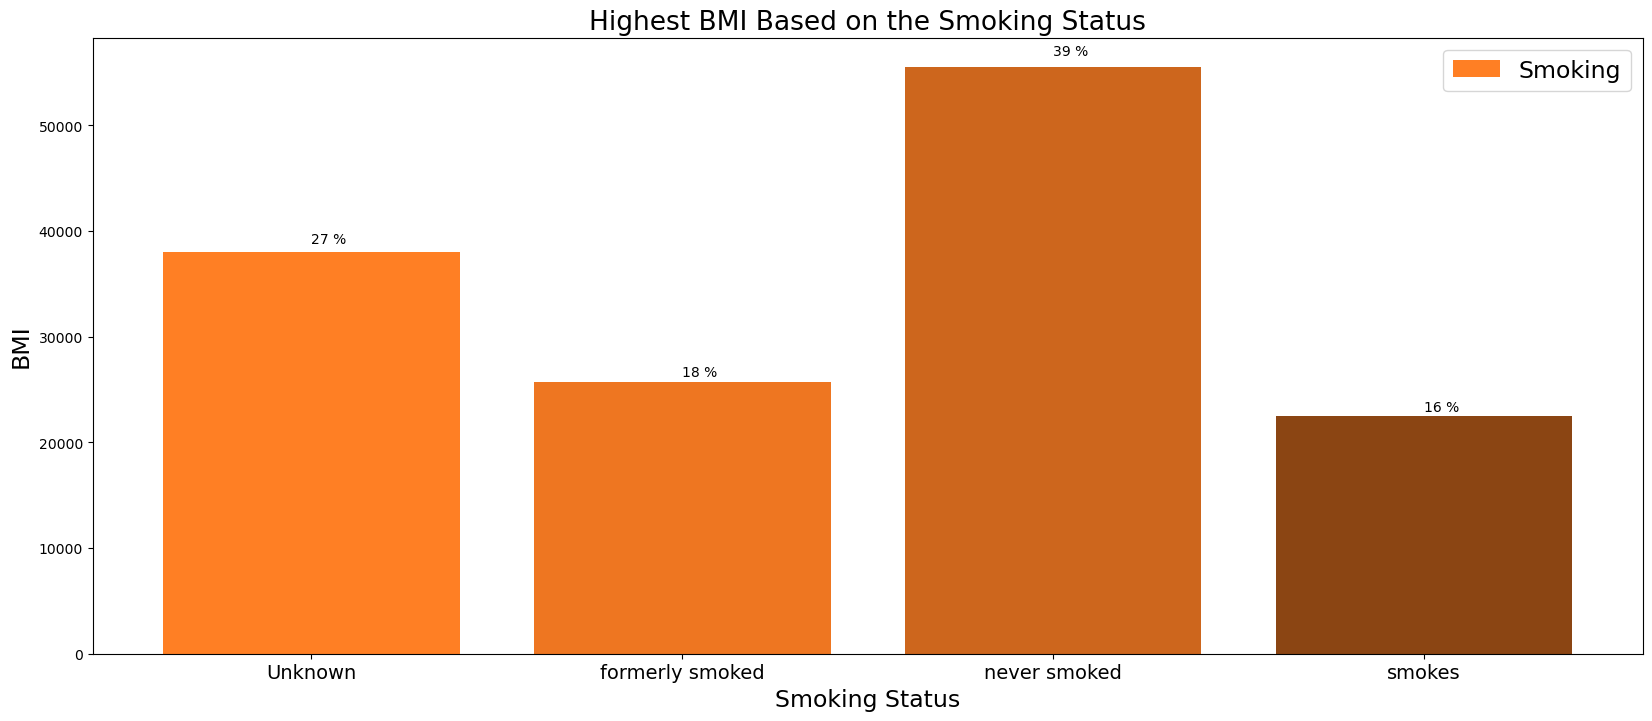

In [17]:
BMI_Percent = MarriedParticipants.bmi.sum()
plt.figure(figsize = (20,8))
HC = MarriedParticipants.index

ax = plt.axes()
x = range(len(MarriedParticipants))
plt.bar(x,MarriedParticipants["bmi"],width=0.8, color=['#FF7F24',"#EE7621","#CD661D","#8B4513"], label="Smoking")

plt.title("Highest BMI Based on the Smoking Status",fontsize=19, color="k")
plt.xlabel("Smoking Status", color="k", fontsize=17)
plt.ylabel("BMI",color="k", fontsize=17)
plt.xticks(x,HC, rotation =360 , fontsize=17, color="k")

plt.title("Highest BMI Based on the Smoking Status",fontsize=19, color="k")
plt.legend(fontsize=17)
plt.xticks(x, MarriedParticipants.index , fontsize= 14)


for x in ax.patches:
    w=x.get_width()
    h=x.get_height()
    x, y =x.get_xy()
    percent= round(h/(BMI_Percent /100))
    percentage = f"{percent} %"
    ax.annotate(percentage, (x+ w/1/2, y+ h*1.02))
plt.savefig('chart1_bmi_smoking.png', bbox_inches='tight', dpi=150)
plt.show()
#People who had never smoked had the highest bmi rate and people who smokes has the lowest bmi rate.

In [18]:
#Question 5: What is the percentage of participants in this dataset based on their work type?

In [19]:
df4 = df.groupby(["work_type"]).size()

In [20]:
Participants = df.work_type.value_counts()

In [21]:
Participants

work_type
Private          2811
Self-employed     775
children          671
Govt_job          630
Never_worked       22
Name: count, dtype: int64

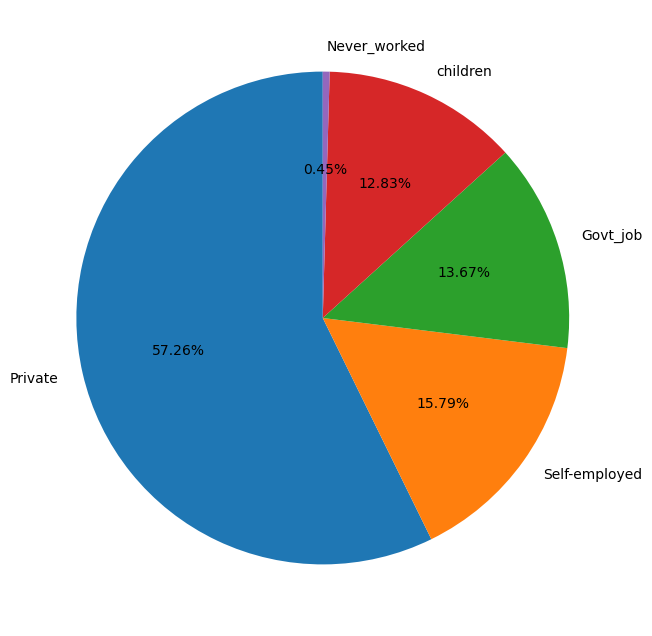

In [22]:
plt.figure(figsize=(20, 8))

work = df.work_type.unique()

plt.pie(Participants, autopct='%.2f%%', labels=work, startangle=90)
plt.savefig('chart2_worktype_pie.png', bbox_inches='tight', dpi=150)
plt.show()
#Private workers has the highest percentage of heart illness while people who never worked had the least

In [23]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1


In [24]:
#Question 6: What is the total number of rural people who had heart disease and lost their lives with a heart stroke?

RuralPeople = df[(df["heart_disease"]==1) & (df["stroke"]==1) & (df["Residence_type"]=="Rural")]


In [25]:
len(RuralPeople)

19

In [26]:
#Question 7: What is the percentage of people who died of heart stroke and had hypertension but didn't have heart disease?

PercentageStroke = df[(df["hypertension"]==1) & (df["stroke"]==1) & (df["heart_disease"]!=1) & (df["gender"]=="Male")]

In [27]:
PercentageStroke.count()*100/100000

id                   0.017
gender               0.017
age                  0.017
hypertension         0.017
heart_disease        0.017
ever_married         0.017
work_type            0.017
Residence_type       0.017
avg_glucose_level    0.017
bmi                  0.017
smoking_status       0.017
stroke               0.017
dtype: float64

In [28]:
#Question 8: What is the percentage of people who has the lowest glucose level based on the work type?

df14 = df.groupby(["work_type"])[["avg_glucose_level"]].sum()
df15 = df14.sort_values("avg_glucose_level", ascending =True)



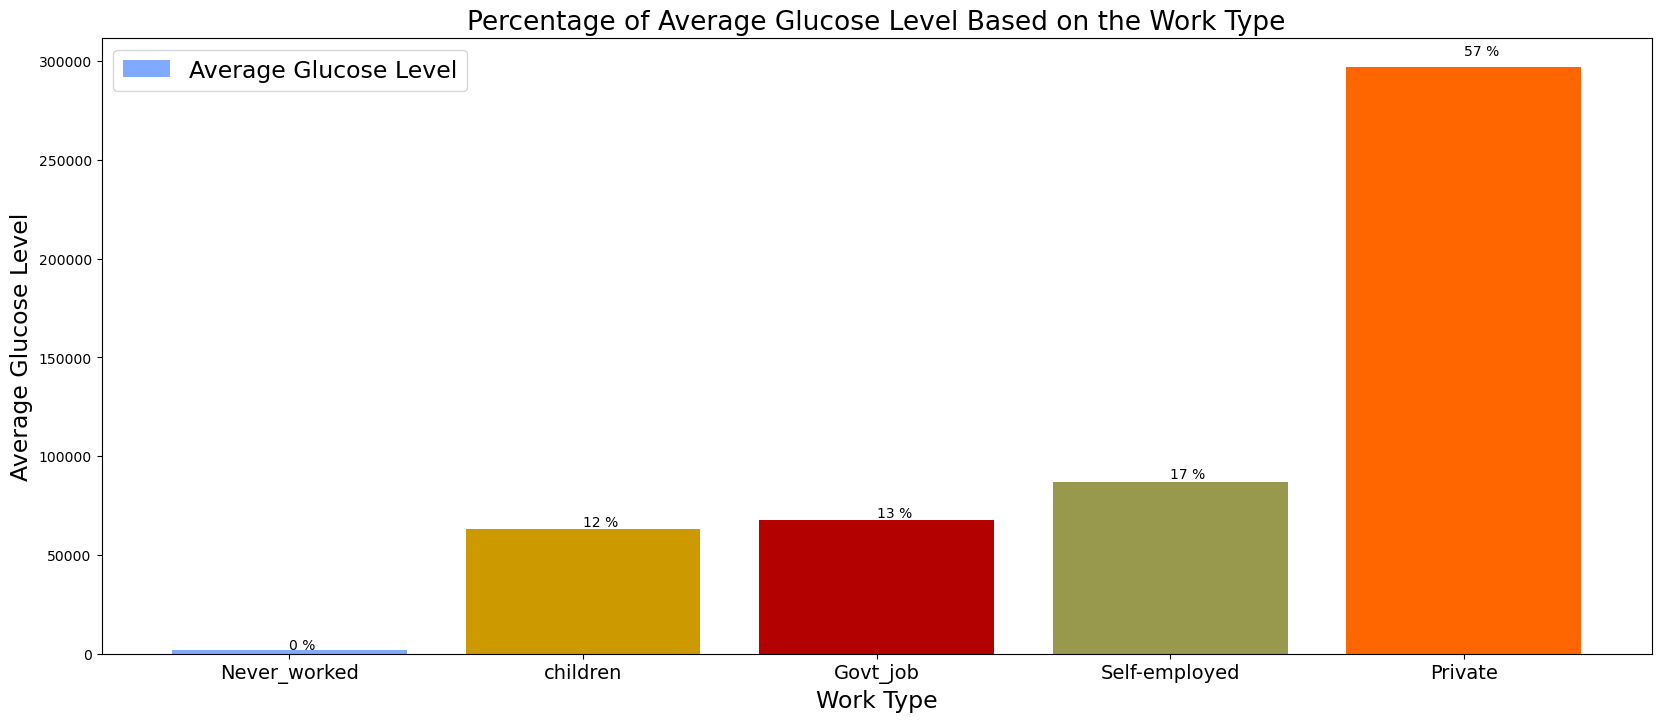

In [29]:
Work_typePercent = df15.avg_glucose_level.sum()

plt.figure(figsize = (20,8))
HC = df15.index

ax = plt.axes()
x = range(len(df15))
plt.bar(x,df15["avg_glucose_level"],width=0.8, color=["#80aaff","#cc9900","#b30000","#99994d","#ff6600"], label="Average Glucose Level")

plt.title("Percentage of Average Glucose Level",fontsize=19, color="k")
plt.xlabel("Work Type", color="k", fontsize=17)
plt.ylabel("Average Glucose Level",color="k", fontsize=17)
plt.xticks(x,HC, rotation =360 , fontsize=17, color="k")

plt.title("Percentage of Average Glucose Level Based on the Work Type",fontsize=19, color="k")
plt.legend(fontsize=17)
plt.xticks(x, df15.index , fontsize= 14)

for x in ax.patches:
    w=x.get_width()
    h=x.get_height()
    x, y =x.get_xy()
    percent= round(h/(Work_typePercent /100))
    percentage = f"{percent} %"
    ax.annotate(percentage, (x+ w/2, y+ h*1.02))
    
plt.savefig('chart3_glucose.png', bbox_inches='tight', dpi=150)
plt.show()    
#Private workers had the highest percentage of glucose level based on work type

In [30]:
df.tail()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
5104,14180,Female,13.0,0,0,No,children,Rural,103.08,18.6,Unknown,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0
5109,44679,Female,44.0,0,0,Yes,Govt_job,Urban,85.28,26.2,Unknown,0


In [31]:
#Question 9: What is the role of gender in causing heart disease and heart stroke?

MaleHDisease = df[(df["gender"]=="Male") & (df["stroke"]==1) & (df["heart_disease"]==1)]

In [32]:
MaleHDisease


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
16,56112,Male,64.0,0,1,Yes,Private,Urban,191.61,37.5,smokes,1
23,64778,Male,82.0,0,1,Yes,Private,Rural,208.30,32.5,Unknown,1
28,54827,Male,69.0,0,1,Yes,Self-employed,Urban,195.23,28.3,smokes,1
33,54401,Male,80.0,0,1,Yes,Self-employed,Urban,252.72,30.5,formerly smoked,1
42,61960,Male,82.0,0,1,Yes,Private,Urban,144.90,26.4,smokes,1
55,25831,Male,63.0,0,1,Yes,Private,Rural,196.71,36.5,formerly smoked,1
86,3253,Male,61.0,0,1,Yes,Private,Rural,111.81,27.3,smokes,1


In [33]:
len(MaleHDisease) #Men are more likely to have heart disease and experience stroke

24

In [34]:
FemaleHDisease = df[(df["gender"]=="Female") & (df["stroke"]==1) & (df["heart_disease"]==1)]

In [35]:
len(FemaleHDisease) #Women are less likely to have heart disease and experience stroke

16

In [36]:
#Question 10: What is the average glucose level in each work type based on the smoking status?

In [37]:
AverageGlucoseLevel = df.groupby(["work_type","smoking_status"])[["avg_glucose_level"]].sum().unstack("smoking_status")

In [38]:
AverageGlucoseLevel

avg_glucose_level                                       
smoking_status           Unknown formerly smoked never smoked    smokes
work_type                                                              
Govt_job                11568.79        14406.17     30069.29  11590.55
Never_worked              742.74             NaN      1370.20       NaN
Private                 62383.04        55424.00    125649.70  53556.32
Self-employed           14977.04        23357.90     35718.84  13047.82
children                56160.57         1041.24      5608.24    270.53

<Figure size 2000x800 with 0 Axes>

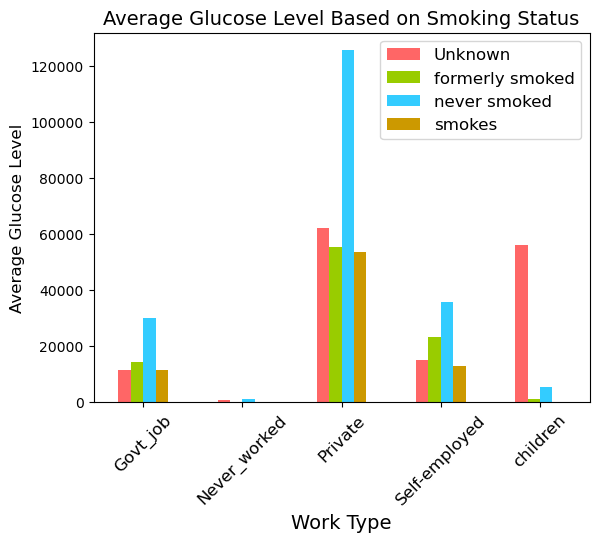

In [39]:
plt.figure(figsize =(20,8))
AverageGlucoseLevel.plot(kind="bar", color=['#ff6666',"#99cc00","#33ccff","#cc9900"])
plt.xticks(rotation=45, fontsize=12)


plt.xlabel("Work Type",fontsize=14)
plt.ylabel("Average Glucose Level", fontsize=12)
plt.title("Average Glucose Level Based on Smoking Status",fontsize=14)
plt.legend(AverageGlucoseLevel.avg_glucose_level, loc="upper right", fontsize=12)
plt.savefig('chart4_glucose_smoking.png', bbox_inches='tight', dpi=150)
plt.show()
#Private workers who never smoked had the highest level of glucose level. Children who smokes have the lowest 
#level of glucose

In [40]:
#Question 11: What is the relationship between heart disease and bmi?

In [41]:
df.groupby("heart_disease").bmi.agg(["max", "min", "count", "mean", "median"]) 

#People who have higher rate of bmi are more likely to have heart diseases

,max,min,count,mean,median
heart_disease,,,,,
0,97.6,10.3,4666,28.819117,27.9
1,54.7,19.1,243,30.316461,29.8


In [42]:
#Question 12: What is the relationship between heart disease and average glucose level?

In [43]:
df.groupby("heart_disease").avg_glucose_level.agg(["max", "min", "count", "mean", "median"]) 

#People who have high level of glucose are more likely to have heart diseases

,max,min,count,mean,median
heart_disease,,,,,
0,267.76,55.12,4666,103.738736,91.05
1,271.74,56.31,243,135.382881,106.41


In [44]:
#Question 13: What is the relationship between heart disease and work type?

In [45]:
df.groupby("work_type").heart_disease.agg(["max", "min", "count", "mean", "median"]) 

#People who had been working on a self-employment basis are more likely to have heart diseases

,max,min,count,mean,median
work_type,,,,,
Govt_job,1,0,630,0.052381,0.0
Never_worked,0,0,22,0.000000,0.0
Private,1,0,2811,0.049449,0.0
Self-employed,1,0,775,0.090323,0.0
children,1,0,671,0.001490,0.0


In [46]:
#Question 14: What is the relationship between heart disease and smoking status?

In [47]:
df.groupby("smoking_status").heart_disease.agg(["max", "min", "count", "mean", "median"]) 

#People who have formerly smoked are more likely to have heart diseases

,max,min,count,mean,median
smoking_status,,,,,
Unknown,1,0,1483,0.024949,0.0
formerly smoked,1,0,837,0.083632,0.0
never smoked,1,0,1852,0.043737,0.0
smokes,1,0,737,0.074627,0.0
